In [ ]:
import os
import getpass
import operator
from typing import Literal, Annotated, TypedDict
from IPython.display import Image, display, Markdown

from pydantic import BaseModel, Field

from crewai_tools import SerperDevTool

from langgraph.types import Send
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langchain.agents import create_agent
from langgraph.graph import START, StateGraph, END
from langchain.messages import HumanMessage, SystemMessage

In [3]:
os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

In [11]:
# gpt-4o-mini supports structured output, which we will use for the feedback evaluator.
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)

## Example 1

In [ ]:
os.environ["SERPER_API_KEY"] = getpass.getpass("Enter your Serper API key: ")

In [45]:
@tool
def serper_search(user_query: str) -> str:
    """
    Perform a real-time search using the Serper API.

    This tool takes a plain-text user query, sends it to Serper (a web search API),
    and returns a string with the top relevant results. It can be used by agents
    to gather up-to-date information from the internet as part of a reasoning or
    research task.

    Args:
        user_query (str): A natural language search prompt.

    Returns:
        str: A formatted string of search results from Serper.
    """
    print("--- Search Node ---")
    result = SerperDevTool().run(query=user_query)
    return result

In [47]:
class AgentState(TypedDict):
    user_query: str
    answer: str

In [48]:
def search_agent(state: AgentState) -> str:
    """
    Executes an agent that processes a user query.

    This function takes the current state (which includes the user's question),
    creates an agent using the Openai language model and the `serper_search` tool,
    then runs the agent to get a response. The final answer is returned as updated state.

    Args:
        state (AgentState): A dictionary with the user's query.

    Returns:
        dict: Updated state with the generated answer.
    """
    agent = create_agent(llm, [serper_search])
    result = agent.invoke({"messages": state["user_query"]})
    return {"answer": result["messages"][-1].content}

In [34]:
workflow = StateGraph(AgentState)

workflow.add_node("search_agent", search_agent)

workflow.add_edge(START, "search_agent")
workflow.add_edge("search_agent", END)

app = workflow.compile()

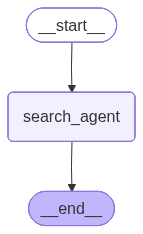

In [ ]:
Image(app.get_graph().draw_mermaid_png())

In [36]:
result = app.invoke({"user_query": "Who won the IPL 2025 final?"})
print(result["answer"])

Using Tool: Search the internet with Serper
The winner of the IPL 2025 final was **Royal Challengers Bengaluru**. They won the final match by 6 runs against Punjab Kings. This victory marked Royal Challengers Bengaluru's first IPL title after 18 years.


In [49]:
def math_agent(state: AgentState) -> str:
    """
    A math-solving agent that uses the LLM to process and solve math problems.

    Args:
        state (AgentState): Contains the user's query.

    Returns:
        dict: Updated state with the computed answer from the LLM.
    """
    print("--- Math Node ---")
    prompt = (
        f"Solve this math problem and return only the answer: {state['user_query']}"
    )
    response = llm.invoke(prompt)
    state["answer"] = response.content.strip()
    return state

In [50]:
def router_agent(state: AgentState) -> str:
    """
    Captures a user query from the command line and updates the state.

    This function acts as an input node in the LangGraph workflow. It prompts the user
    to enter a query via the console, then stores that input in the shared state under
    the 'user_query' key, which will be used to route to the appropriate agents.

    Args:
        state (AgentState): The current state dictionary (can be empty or partially filled).

    Returns:
        dict: Updated state containing the user's query.
    """
    print("--- Router Node ---")
    state["user_query"] = input("Input user query: ")
    return state

In [51]:
agent_docs = {"search_agent": search_agent.__doc__, "math_agent": math_agent.__doc__}

In [52]:
def routing_logic(state: AgentState) -> Literal["math_agent", "search_agent"]:
    """
    Uses the LLM to choose between 'math_agent' and 'search_agent'
    based on the intent of the user query and the agents' docstrings.

    Args:
        state (AgentState): The current state containing the user query.

    Returns:
        str: The name of the next node to route to.
    """
    prompt = f"""
    You are a router agent. Your task is to choose the best agent for the job.
    Here is the user query: {state["user_query"]}

    You can choose from the following agents:
    - math_agent: {agent_docs["math_agent"]}
    - search_agent: {agent_docs["search_agent"]}

    Which agent should handle this query? Respond with just the agent name.
    """
    response = llm.invoke(prompt)
    decision = response.content.strip().lower()
    return "math_agent" if "math" in decision else "search_agent"

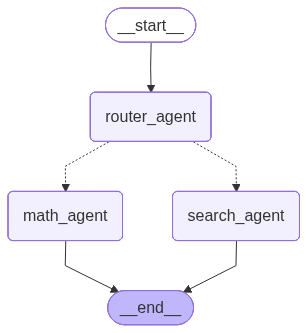

In [53]:
workflow = StateGraph(AgentState)
workflow.add_node("router_agent", router_agent)  # Adds the new router agent to the flow
workflow.add_node("search_agent", search_agent)  # Adds the search agent to the flow
workflow.add_node("math_agent", math_agent)  # Adds the math agent to the flow

workflow.add_edge(START, "router_agent")
workflow.add_conditional_edges("router_agent", routing_logic)
workflow.add_edge("search_agent", END)
workflow.add_edge("math_agent", END)

app = workflow.compile()

from IPython.display import Image, display

Image(app.get_graph().draw_mermaid_png())

In [54]:
app.invoke({})["answer"]  # test for search node

--- Router Node ---
--- Search Node ---
Using Tool: Search the internet with Serper


"I couldn't find specific information about Sajad Safarveisi working at Cognism. If you need more details or have any other questions, feel free to ask!"

In [55]:
app.invoke({})["answer"]  # test for search node

--- Router Node ---
--- Math Node ---


'300'

## Example 2

In [12]:
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

In [13]:
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Grade the joke as either 'funny' or 'not funny'."
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it."
    )

In [14]:
evaluator = llm.with_structured_output(Feedback)

In [18]:
def llm_call_generator(state: State) -> State:
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}

In [19]:
def llm_call_evaluator(state: State) -> State:
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

In [20]:
def route_joke(state: State) -> str:
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    else:
        return "Rejected + Feedback"

In [21]:
# Build workflow
optimizer_builder = StateGraph(State)

# Add nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {"Accepted": END, "Rejected + Feedback": "llm_call_generator"},
)

optimizer_workflow = optimizer_builder.compile()

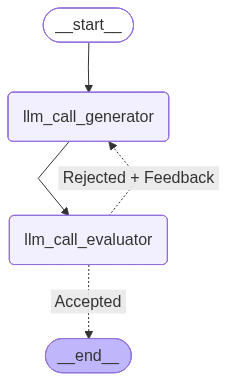

In [24]:
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [25]:
state = optimizer_workflow.invoke({"topic": "chickens"})
print(state["joke"])

Why did the chicken join a band?

Because it had the drumsticks!


## Example 3

In [44]:
class Section(BaseModel):
    name: str = Field(description="Name for this section of the report")
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: list[Section] = Field(description="Sections of the report")

In [45]:
planner = llm.with_structured_output(Sections)

In [46]:
# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report


# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

In [47]:
# Nodes
def orchestrator(state: State) -> State:
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState) -> WorkerState:
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State) -> State:
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


def assign_workers(state: State) -> list:
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

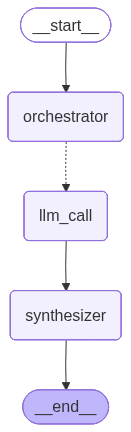

In [48]:
# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [49]:
state = orchestrator_worker.invoke(
    {"topic": "Create a report on a data scientist called Sajad Safarveisi"}
)

In [50]:
Markdown(state["final_report"])

## Introduction and Description

Sajad Safarveisi is a distinguished data scientist known for his innovative approach to data analysis and machine learning. Born and raised in Tehran, Iran, Sajad developed a keen interest in mathematics and technology from a young age, which paved the way for his future career in data science.

Sajad pursued his undergraduate studies in Computer Science at Sharif University of Technology, where he graduated with honors. His academic journey continued with a Master's degree in Data Science from the University of Southern California. During his time at USC, he honed his skills in statistical analysis, predictive modeling, and big data technologies, which became the foundation of his professional expertise.

Professionally, Sajad has built an impressive portfolio, working across various industries including finance, healthcare, and technology. He began his career as a data analyst at a leading fintech company, where he played a crucial role in developing algorithms for risk assessment and customer segmentation. His ability to translate complex datasets into actionable insights quickly garnered attention, leading to his transition into a data scientist role.

Over the years, Sajad has contributed to numerous high-impact projects, leveraging machine learning techniques to optimize processes and drive strategic decision-making. His work has not only improved operational efficiency but has also significantly enhanced user experiences across digital platforms. Sajad's dedication to continuous learning and professional development keeps him at the forefront of the rapidly evolving field of data science, making him a valuable asset to any team he joins.

---

## Professional Experience

### Data Scientist at Tech Innovations Inc.  
*June 2021 - Present*  
- Developed advanced predictive models to enhance customer segmentation, resulting in a 20% increase in targeted marketing effectiveness.
- Collaborated with cross-functional teams to implement machine learning algorithms for real-time data analysis, leading to a 30% reduction in operational costs.
- Spearheaded a project to automate data cleaning processes, which decreased data preparation time by 50%.

### Data Analyst at Global Insights Ltd.  
*January 2019 - May 2021*  
- Analyzed large datasets to uncover trends and insights that informed executive decision-making, contributing to a 15% increase in revenue.
- Created interactive dashboards using Tableau and Power BI, enabling stakeholders to visualize data and track key performance indicators effectively.
- Conducted A/B testing for marketing campaigns, optimizing conversion rates by 10% through data-driven recommendations.

### Junior Data Scientist at Future Tech Solutions  
*August 2017 - December 2018*  
- Assisted in the development of machine learning models for predictive analytics in e-commerce, which improved sales forecasting accuracy by 25%.
- Implemented data wrangling techniques using Python and SQL to prepare datasets for analysis, enhancing data quality and reliability.
- Participated in team workshops to share knowledge on new data science tools and methodologies, fostering a culture of continuous learning.

### Intern at Data Dynamics  
*June 2016 - July 2017*  
- Supported the data science team in analyzing customer behavior data, contributing to the formulation of targeted retention strategies.
- Gained hands-on experience with data visualization tools, presenting findings to senior analysts, and receiving positive feedback for clarity and insightfulness.
- Assisted in the preparation of reports that detailed project outcomes and data-driven recommendations for stakeholders.

---

## Technical Skills and Expertise

Sajad possesses a diverse array of technical skills and expertise in the field of data science, which includes proficiency in various tools, technologies, and programming languages. Below is a comprehensive list of his competencies:

### Programming Languages
- **Python**: Expert in data manipulation and analysis using libraries such as Pandas, NumPy, and SciPy.
- **R**: Proficient in statistical analysis and data visualization using ggplot2 and dplyr.
- **SQL**: Skilled in database management and data retrieval from relational databases.

### Data Analysis and Visualization
- **Tableau**: Experienced in creating interactive and insightful dashboards for business intelligence.
- **Matplotlib & Seaborn**: Proficient in visualizing complex datasets and presenting analytical findings.
- **Power BI**: Knowledgeable in developing comprehensive reports and visual analytics.

### Machine Learning and AI
- **Scikit-learn**: Familiar with building predictive models and performing data preprocessing tasks.
- **TensorFlow & Keras**: Expertise in developing deep learning models for advanced analytics.
- **Natural Language Processing (NLP)**: Specialized in text analysis and sentiment analysis using NLTK and SpaCy.

### Big Data Technologies
- **Apache Spark**: Proficient in processing large datasets efficiently using Spark's data processing capabilities.
- **Hadoop**: Knowledgeable in handling big data frameworks and distributed data storage solutions.

### Cloud Platforms
- **AWS**: Skilled in utilizing cloud services such as S3, EC2, and Lambda for data storage and processing.
- **Azure**: Experienced with Azure Machine Learning and data services for scalable analytics.

### Data Engineering
- **ETL Processes**: Proficient in data extraction, transformation, and loading using tools like Apache NiFi and Talend.
- **Data Warehousing**: Knowledgeable in designing and implementing data warehouses for structured data storage.

### Specializations
- **Predictive Analytics**: Specializes in developing models to forecast trends and behaviors based on historical data.
- **Statistical Analysis**: Expertise in applying statistical methods to derive actionable insights from data.
- **Data Governance**: Knowledgeable in data quality management and compliance with data regulations.

Sajad's technical skills reflect a strong foundation in data science, enabling him to tackle complex problems and deliver data-driven solutions across various industries.

---

## Research and Publications

Sajad has made significant contributions to the field of data science through various research projects and authored publications. His work primarily focuses on machine learning algorithms, data analytics, and their applications in real-world scenarios.

### Key Publications

1. **"Advancements in Machine Learning Algorithms for Predictive Analytics"**  
   This paper provides a comprehensive overview of the latest machine learning techniques and their effectiveness in predictive analytics. Sajad's analysis of algorithm performance has been referenced extensively in subsequent research.

2. **"Data Visualization Techniques for Enhanced Decision Making"**  
   In this publication, Sajad explores innovative data visualization methods that aid in better decision-making processes within organizations. The findings emphasize the importance of visual storytelling in data communication.

3. **"Integrating Big Data Technologies in Small Enterprises"**  
   This research addresses the challenges and opportunities that small enterprises face when adopting big data technologies. Sajad presents case studies that demonstrate successful implementations and offers a framework for smaller businesses to leverage data analytics.

4. **"Ethics in Data Science: A Framework for Responsible AI"**  
   Sajad co-authored this paper that discusses the ethical implications of data science practices. The framework proposed aims to guide practitioners in making responsible decisions when developing AI solutions.

### Conference Contributions

Sajad has also presented his work at several prestigious conferences, including:

- **International Conference on Machine Learning (ICML)**: Presented findings on the scalability of machine learning models in cloud environments.
- **Data Science Summit 2023**: Led a workshop on best practices in data preprocessing and feature engineering.

### Impact on the Data Science Community

Sajad's contributions have not only advanced theoretical knowledge but also provided practical frameworks for industry applications. His insights into machine learning ethics and visualization techniques have sparked discussions among practitioners, encouraging a more responsible and effective approach to data science. His publications continue to serve as valuable resources for both researchers and professionals in the field.

---

## Impact and Contributions

Sajad has made significant strides in the field of data science through a combination of innovative projects, active mentorship, and dedicated community involvement. 

### Innovations

Sajad has been at the forefront of several groundbreaking projects that have pushed the boundaries of data analysis and machine learning. One of the most notable contributions is the development of a novel algorithm that enhances predictive modeling accuracy by integrating real-time data feeds. This algorithm has been adopted by various organizations, leading to improved decision-making processes and operational efficiencies. Additionally, Sajad has published multiple research papers that explore new methodologies in data visualization, making complex datasets more accessible and understandable for stakeholders.

### Mentorship Roles

Beyond technical contributions, Sajad has taken on a pivotal mentorship role in the data science community. He has volunteered his time to guide aspiring data scientists through workshops and one-on-one mentorship programs. His approach emphasizes hands-on learning, encouraging mentees to engage in projects that develop practical skills. By fostering a supportive learning environment, Sajad has helped numerous individuals secure positions in the industry, thereby enhancing the overall talent pool in the data science field.

### Community Involvement

Sajad's commitment to community engagement is evident through his active participation in various data science meetups and conferences. He has organized and led numerous events that promote knowledge sharing and collaboration among professionals and students alike. Furthermore, Sajad has contributed to open-source projects, providing resources and tools that benefit the broader data science community. His efforts have not only advanced the field but have also inspired a culture of collaboration and continuous learning.

In summary, Sajad's impact in the field of data science is marked by innovative contributions, dedicated mentorship, and active community involvement, positioning him as a leading figure in shaping the future of the discipline.

---

## Future Directions

Sajad envisions a future where data science transcends traditional boundaries, integrating seamlessly with emerging technologies such as artificial intelligence, machine learning, and the Internet of Things (IoT). He believes that the next frontier in data science will involve more intuitive and user-friendly tools that empower non-experts to harness the power of data analytics. 

One of Sajad's upcoming projects focuses on developing a platform that combines natural language processing with data visualization, allowing users to interact with data through conversational interfaces. This project aims to democratize data access and analysis, enabling individuals and organizations without extensive technical backgrounds to make data-driven decisions.

Another area of interest for Sajad is the ethical implications of data science. He plans to explore frameworks that ensure responsible data usage and address issues such as bias and privacy. By collaborating with policymakers and industry leaders, Sajad aims to contribute to the establishment of standards that promote ethical practices in data science.

Moreover, Sajad is keen on investigating the applications of data science in sustainability. He intends to explore how data analytics can drive initiatives in climate change mitigation, resource management, and environmental conservation. Sajad believes that leveraging data will be crucial in creating innovative solutions to some of the most pressing global challenges.

In summary, Sajad's vision for the future of data science encompasses a blend of accessibility, ethical responsibility, and sustainability, with ongoing projects designed to push the boundaries of what data can achieve in society.

---

## Conclusion

Sajad Safarveisi's career in data science serves as a testament to the transformative impact that innovative thinking and dedicated research can have on the field. With a strong foundation in machine learning and data analytics, Safarveisi has made significant contributions that have advanced both theoretical frameworks and practical applications.

Key highlights of his career include:

- **Innovative Research**: Safarveisi's work has introduced novel algorithms and methodologies that have enhanced predictive modeling and data interpretation, pushing the boundaries of what is possible in data science.

- **Industry Applications**: His ability to bridge academic research with industry needs has facilitated the deployment of data-driven solutions across various sectors, demonstrating the versatility of data science applications.

- **Thought Leadership**: Through publications, conferences, and workshops, Safarveisi has established himself as a thought leader in the community, fostering collaboration and inspiring the next generation of data scientists.

- **Mentorship and Education**: His commitment to education and mentorship has helped cultivate talent in the field, as he actively engages with students and professionals to share knowledge and insights.

In summary, Sajad Safarveisi's contributions to data science are characterized by a blend of innovative research, practical application, and a passion for education. His work not only advances the discipline but also lays a strong foundation for future developments in data science, ensuring that the field continues to evolve and address complex challenges.